# Concept manifold (3D UMAP) — pooled from `bars_judged.csv`

`bars_judged.csv` covers many more concepts than `confusion_judged.csv` (e.g. 91 in conceptvectors, 200 in rwku). Pool every `(dataset, concept, question)` triple, embed with `all-MiniLM-L6-v2`, average per concept, and project the union of question + centroid vectors to 3D with UMAP. Bold red links connect the closest concept pairs; a few are labeled.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "store").exists():
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "inference" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PALETTE = {
    "inhouse": "#005493",
    "conceptvectors": "#B30000",
    "rwku": "#E87D1E",
    "mmlu": "#008080",
    "concept10": "#7B2D8E",
    "concept500": "#2E7D32",
}

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Pool all (dataset, concept, question) triples from bars_judged across stores
bar_paths = sorted((REPO_ROOT / "store").glob("*/bars_judged.csv"))
frames = []
for p in bar_paths:
    store = p.parent.name              # e.g. llama8b_conceptvectors
    dataset = store.split("_", 1)[1] if "_" in store else store
    df = pd.read_csv(p, usecols=["concept", "question"])
    df["dataset"] = dataset
    frames.append(df)
pool = (pd.concat(frames, ignore_index=True)
          .dropna(subset=["concept", "question"])
          .drop_duplicates(["dataset", "concept", "question"])
          .reset_index(drop=True))
print("pooled rows:", len(pool),
      " datasets:", sorted(pool["dataset"].unique()),
      " unique (dataset,concept):", pool[['dataset','concept']].drop_duplicates().shape[0])

pooled rows: 5171  datasets: ['conceptvectors', 'inhouse', 'mmlu', 'rwku']  unique (dataset,concept): 311


In [3]:
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
q_emb = encoder.encode(pool["question"].tolist(), batch_size=128,
                       show_progress_bar=True, normalize_embeddings=True)
q_emb = np.asarray(q_emb)
print("q_emb:", q_emb.shape)

concept_keys = (pool[["dataset", "concept"]].drop_duplicates()
                  .reset_index(drop=True))
centroids = np.zeros((len(concept_keys), q_emb.shape[1]), dtype=np.float32)
for i, row in concept_keys.iterrows():
    mask = (pool["dataset"] == row["dataset"]) & (pool["concept"] == row["concept"])
    v = q_emb[mask.to_numpy()].mean(axis=0)
    centroids[i] = v / (np.linalg.norm(v) + 1e-12)
print("centroids:", centroids.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17610.91it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   2%|▏         | 1/41 [00:00<00:16,  2.46it/s]

Batches:   7%|▋         | 3/41 [00:00<00:06,  5.69it/s]

...

Batches:  80%|████████  | 33/41 [00:02<00:00, 17.13it/s]

Batches:  93%|█████████▎| 38/41 [00:02<00:00, 24.78it/s]

Batches: 100%|██████████| 41/41 [00:02<00:00, 21.17it/s]

Batches: 100%|██████████| 41/41 [00:02<00:00, 14.62it/s]

q_emb: (5171, 384)
centroids: (311, 384)


In [4]:
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.6,
                    spread=1.5, metric="cosine", random_state=0)
all_3d = reducer.fit_transform(np.vstack([q_emb, centroids]))
q_3d = all_3d[: len(q_emb)]
c_3d = all_3d[len(q_emb):]
print("projected:", all_3d.shape)

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


projected: (5482, 3)


In [5]:
# Closest concept pairs in the original embedding space (cosine)
TOP_K = 10
LABEL_TOP = 5
sim = cosine_similarity(centroids)
iu = np.triu_indices_from(sim, k=1)
order = np.argsort(-sim[iu])
top_pairs = [(int(iu[0][k]), int(iu[1][k])) for k in order[:TOP_K]]
top_sims = [float(sim[iu[0][k], iu[1][k]]) for k in order[:TOP_K]]
LABEL_PAIRS = top_pairs[:LABEL_TOP]

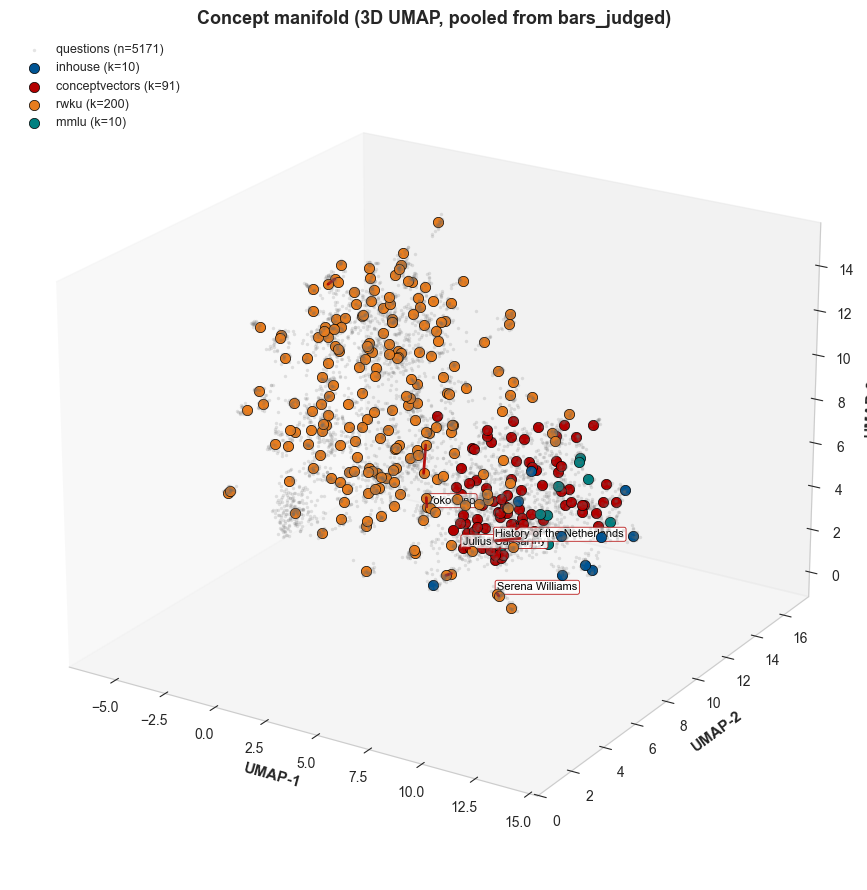

     a_dataset                  a_concept      b_dataset         b_concept   cosine
          rwku            Serena Williams           rwku    Venus Williams 0.887520
conceptvectors                    Germany conceptvectors           Austria 0.788741
conceptvectors              Julius Caesar conceptvectors      Ancient Rome 0.781929
conceptvectors History of the Netherlands conceptvectors       Netherlands 0.780878
          rwku                   Yoko Ono           rwku       John Lennon 0.774000
conceptvectors             United Kingdom conceptvectors           England 0.769525
conceptvectors              Islamic State conceptvectors             Islam 0.750826
          rwku          Kiefer Sutherland           rwku Donald Sutherland 0.748727
          rwku                   Socrates           rwku         Aristotle 0.748103
          rwku                Kris Jenner           rwku      Kylie Jenner 0.745302


In [6]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(q_3d[:, 0], q_3d[:, 1], q_3d[:, 2], s=6, alpha=0.18, color="#6B6B6B",
           linewidths=0, label=f"questions (n={len(q_3d)})", depthshade=False)

for ds, color in DATASET_PALETTE.items():
    mask = (concept_keys["dataset"] == ds).to_numpy()
    if not mask.any():
        continue
    ax.scatter(c_3d[mask, 0], c_3d[mask, 1], c_3d[mask, 2],
               s=55, color=color, edgecolors="black", linewidths=0.5,
               label=f"{ds} (k={int(mask.sum())})", depthshade=False)

for (i, j) in top_pairs:
    a, b = c_3d[i], c_3d[j]
    ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
            color="#B30000", linewidth=2.0, alpha=0.95, zorder=5)

def _short(name, n=42):
    return name if len(name) <= n else name[: n - 1] + "\u2026"

labelled = set()
for (i, j) in LABEL_PAIRS:
    pick = i if i not in labelled else j
    labelled.add(pick)
    c = concept_keys.iloc[pick]["concept"]
    ax.text(c_3d[pick, 0], c_3d[pick, 1], c_3d[pick, 2] + 0.15,
            _short(c), fontsize=8, color="black",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                      edgecolor="#B30000", linewidth=0.6, alpha=0.9))

ax.set_xlabel("UMAP-1", fontsize=11, fontweight="bold")
ax.set_ylabel("UMAP-2", fontsize=11, fontweight="bold")
ax.set_zlabel("UMAP-3", fontsize=11, fontweight="bold")
ax.set_title("Concept manifold (3D UMAP, pooled from bars_judged)",
             fontsize=13, fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.grid(False)
ax.view_init(elev=22, azim=-58)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "manifold_bars_3d.png", dpi=300)
fig.savefig(RESULTS_DIR / "manifold_bars_3d.pdf", dpi=300)
plt.show()

top_table = pd.DataFrame([
    {"a_dataset": concept_keys.iloc[i]["dataset"],
     "a_concept": concept_keys.iloc[i]["concept"],
     "b_dataset": concept_keys.iloc[j]["dataset"],
     "b_concept": concept_keys.iloc[j]["concept"],
     "cosine": float(s)}
    for (i, j), s in zip(top_pairs, top_sims)
])
top_table.to_csv(RESULTS_DIR / "manifold_bars_top_pairs.csv", index=False)
print(top_table.to_string(index=False))

## Smooth 2D manifold with halo + example pairs

Project to 2D UMAP, draw a KDE-filled "halo" around the question cloud to read as a smooth manifold surface, overlay concept centroids colored by dataset, and highlight one **high-similarity** and one **low-similarity** example pair with connector lines and labels.

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


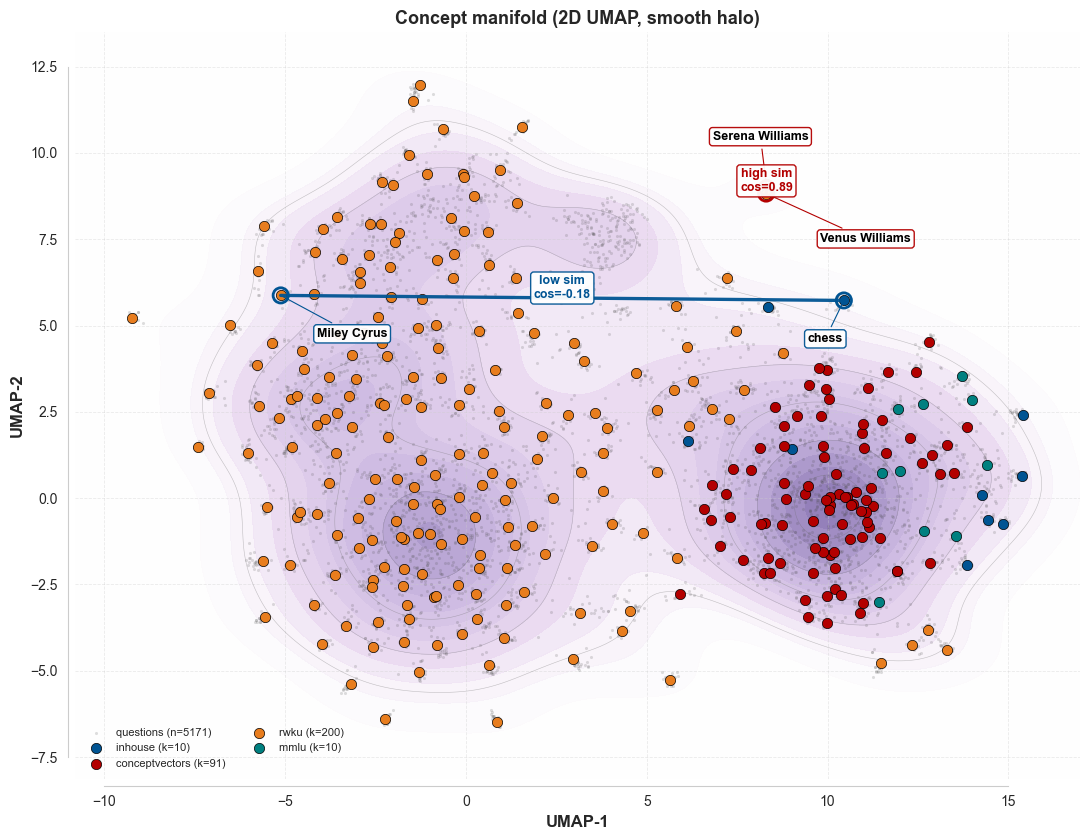

high-sim pair: Serena Williams  <->  Venus Williams  cos=0.888
low-sim pair:  chess  <->  Miley Cyrus  cos=-0.181


In [7]:
from scipy.stats import gaussian_kde

# 2D UMAP on the same union (questions + centroids)
reducer2d = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.5,
                      spread=1.5, metric="cosine", random_state=0)
all_2d = reducer2d.fit_transform(np.vstack([q_emb, centroids]))
q_2d = all_2d[: len(q_emb)]
c_2d = all_2d[len(q_emb):]

# KDE on question points -> smooth halo
kde = gaussian_kde(q_2d.T, bw_method=0.25)
x_min, x_max = q_2d[:, 0].min() - 1.5, q_2d[:, 0].max() + 1.5
y_min, y_max = q_2d[:, 1].min() - 1.5, q_2d[:, 1].max() + 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Pick one high-sim and one low-sim pair (cross-concept, different concepts)
iu = np.triu_indices_from(sim, k=1)
vals = sim[iu]
hi_k = int(np.argmax(vals))
lo_k = int(np.argmin(vals))
hi_pair = (int(iu[0][hi_k]), int(iu[1][hi_k]))
lo_pair = (int(iu[0][lo_k]), int(iu[1][lo_k]))
hi_sim, lo_sim = float(vals[hi_k]), float(vals[lo_k])

fig, ax = plt.subplots(figsize=(11, 8.5))

halo_cmap = LinearSegmentedColormap.from_list(
    "halo", [(1, 1, 1, 0), "#EAD9F0", "#C9B6E0", "#8E7AB5"])
ax.contourf(xx, yy, zz, levels=14, cmap=halo_cmap, zorder=0)
ax.contour(xx, yy, zz, levels=6, colors="#6B6B6B",
           linewidths=0.4, alpha=0.4, zorder=1)

ax.scatter(q_2d[:, 0], q_2d[:, 1], s=5, alpha=0.18, color="#4A4A4A",
           linewidths=0, zorder=2, label=f"questions (n={len(q_2d)})")

for ds, color in DATASET_PALETTE.items():
    mask = (concept_keys["dataset"] == ds).to_numpy()
    if not mask.any():
        continue
    ax.scatter(c_2d[mask, 0], c_2d[mask, 1], s=55, color=color,
               edgecolors="black", linewidths=0.5, zorder=4,
               label=f"{ds} (k={int(mask.sum())})")

def _draw_pair(pair, color, label, sim_val, off_a=(0.5, 0.5), off_b=(0.5, -0.5)):
    i, j = pair
    a, b = c_2d[i], c_2d[j]
    ax.plot([a[0], b[0]], [a[1], b[1]], color=color, linewidth=2.4,
            alpha=0.95, zorder=5)
    ax.scatter([a[0], b[0]], [a[1], b[1]], s=120,
               facecolors="none", edgecolors=color, linewidths=2.0, zorder=6)
    for k, pt, off in [(i, a, off_a), (j, b, off_b)]:
        name = concept_keys.iloc[k]["concept"]
        if len(name) > 38:
            name = name[:37] + "\u2026"
        ax.annotate(name, xy=(pt[0], pt[1]),
                    xytext=(pt[0] + off[0], pt[1] + off[1]),
                    fontsize=9, fontweight="bold", color="black",
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                              edgecolor=color, linewidth=1.0, alpha=0.95),
                    arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
                    zorder=7)
    mid = ((a[0] + b[0]) / 2, (a[1] + b[1]) / 2)
    ax.text(mid[0], mid[1], f"{label}\ncos={sim_val:.2f}",
            fontsize=9, fontweight="bold", color=color, ha="center",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=color, linewidth=1.0, alpha=0.95), zorder=7)

_draw_pair(hi_pair, "#B30000", "high sim", hi_sim, off_a=(-1.5, 1.4), off_b=(1.5, -1.4))
_draw_pair(lo_pair, "#005493", "low sim", lo_sim, off_a=(-1.0, -1.2), off_b=(1.0, -1.2))

ax.set_xlabel("UMAP-1", fontsize=12, fontweight="bold")
ax.set_ylabel("UMAP-2", fontsize=12, fontweight="bold")
ax.set_title("Concept manifold (2D UMAP, smooth halo)",
             fontsize=13, fontweight="bold")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend(frameon=False, loc="lower left", fontsize=8, ncol=2)
sns.despine(ax=ax, trim=True, offset=5)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "manifold_bars_halo.png", dpi=300)
fig.savefig(RESULTS_DIR / "manifold_bars_halo.pdf", dpi=300)
plt.show()

print(f"high-sim pair: {concept_keys.iloc[hi_pair[0]]['concept']}  <->  "
      f"{concept_keys.iloc[hi_pair[1]]['concept']}  cos={hi_sim:.3f}")
print(f"low-sim pair:  {concept_keys.iloc[lo_pair[0]]['concept']}  <->  "
      f"{concept_keys.iloc[lo_pair[1]]['concept']}  cos={lo_sim:.3f}")

## 3D halo manifold

Fit a smooth manifold surface around the question cloud in 3D by computing a Gaussian KDE on the 3D UMAP points, extracting an isosurface with marching cubes, and rendering it as a translucent shell. Points are gray (no dataset distinction); the same high-sim and low-sim example pairs are highlighted with thick connector lines and labels.

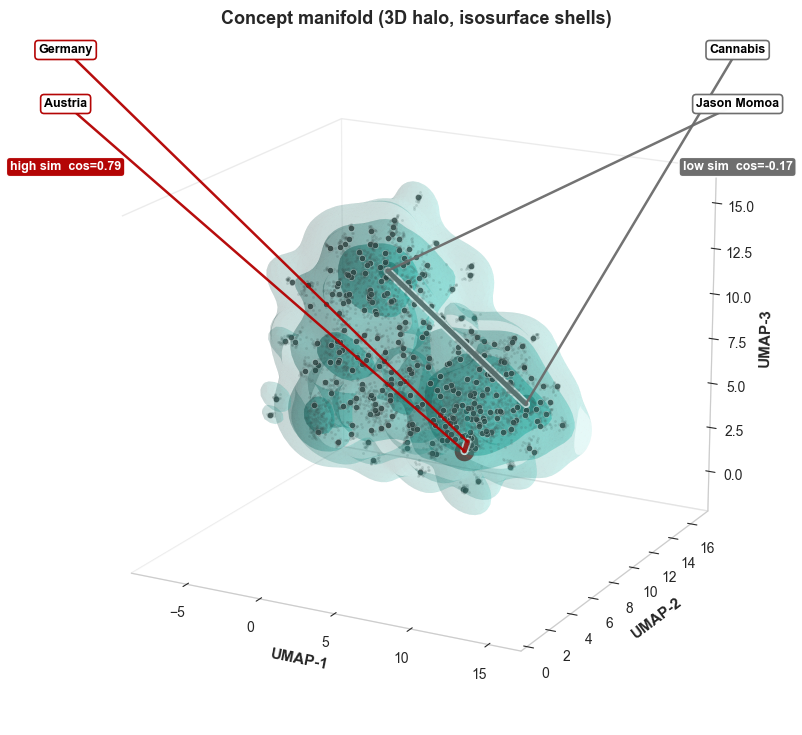

high-sim pair (3D): Germany  <->  Austria  cos=0.789
low-sim pair  (3D): Cannabis  <->  Jason Momoa  cos=-0.168


In [8]:
from scipy.stats import gaussian_kde
from skimage import measure
from mpl_toolkits.mplot3d import proj3d
from sklearn.cluster import KMeans

# 3D KDE on the question cloud
kde3d = gaussian_kde(q_3d.T, bw_method=0.30)

pad = 1.5
xb = (q_3d[:, 0].min() - pad, q_3d[:, 0].max() + pad)
yb = (q_3d[:, 1].min() - pad, q_3d[:, 1].max() + pad)
zb = (q_3d[:, 2].min() - pad, q_3d[:, 2].max() + pad)

G = 60
xs = np.linspace(*xb, G)
ys = np.linspace(*yb, G)
zs = np.linspace(*zb, G)
X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
density = kde3d(np.vstack([X.ravel(), Y.ravel(), Z.ravel()])).reshape(G, G, G)
dmax = float(density.max())

# --- Pick example pairs that visually live in different regions ---
# k-means on 3D UMAP coords splits the manifold; high-sim INSIDE the smaller
# cluster, low-sim ACROSS the two clusters.
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(c_3d)
cl = km.labels_
c_density = kde3d(c_3d.T)
deep = (c_density / c_density.max()) >= 0.25

hi_pair_3d, hi_sim_3d = None, -np.inf
for i in range(len(c_3d)):
    if not deep[i]:
        continue
    for j in range(i + 1, len(c_3d)):
        if not deep[j] or cl[i] != cl[j]:
            continue
        if sim[i, j] > hi_sim_3d:
            hi_pair_3d, hi_sim_3d = (i, j), sim[i, j]

lo_pair_3d, lo_sim_3d = None, np.inf
for i in range(len(c_3d)):
    if not deep[i]:
        continue
    for j in range(i + 1, len(c_3d)):
        if not deep[j] or cl[i] == cl[j]:
            continue
        if sim[i, j] < lo_sim_3d:
            lo_pair_3d, lo_sim_3d = (i, j), sim[i, j]

hi_sim_3d = float(hi_sim_3d)
lo_sim_3d = float(lo_sim_3d)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

shell_levels = [0.06, 0.20, 0.45]
shell_alphas = [0.12, 0.20, 0.32]
shell_colors = ["#30D5C8", "#30D5C8", "#30D5C8"]  # exact turquoise #30D5C8
spacing = (xs[1] - xs[0], ys[1] - ys[0], zs[1] - zs[0])
origin = (xb[0], yb[0], zb[0])
for level_frac, alpha, color in zip(shell_levels, shell_alphas, shell_colors):
    iso = level_frac * dmax
    if iso <= density.min() or iso >= density.max():
        continue
    verts, faces, _, _ = measure.marching_cubes(density, level=iso, spacing=spacing)
    verts = verts + np.array(origin)
    ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                    color=color, alpha=alpha, linewidth=0,
                    antialiased=True, shade=True, zorder=1)

ax.scatter(q_3d[:, 0], q_3d[:, 1], q_3d[:, 2], s=4, alpha=0.18, color="#4A4A4A",
           linewidths=0, depthshade=False, zorder=3)
ax.scatter(c_3d[:, 0], c_3d[:, 1], c_3d[:, 2], s=20, alpha=0.75, color="#2A2A2A",
           edgecolors="white", linewidths=0.4, depthshade=False, zorder=4)

ax.set_xlabel("UMAP-1", fontsize=11, fontweight="bold")
ax.set_ylabel("UMAP-2", fontsize=11, fontweight="bold")
ax.set_zlabel("UMAP-3", fontsize=11, fontweight="bold")
ax.set_title("Concept manifold (3D halo, isosurface shells)",
             fontsize=13, fontweight="bold")
ax.grid(False)
ax.view_init(elev=18, azim=-62)
ax.set_box_aspect((1, 1, 0.85))
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor((0.85, 0.85, 0.85, 0.6))

# Bold colored circles + connector lines for both pairs
for pair, color in [(hi_pair_3d, "#B30000"), (lo_pair_3d, "#6B6B6B")]:
    a, b = c_3d[pair[0]], c_3d[pair[1]]
    ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
            color="white", linewidth=6.0, alpha=0.9, zorder=6)
    ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
            color=color, linewidth=3.5, alpha=1.0, zorder=7)
    ax.scatter([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
               s=260, facecolors=color, edgecolors="white",
               linewidths=2.0, marker="o", depthshade=False, zorder=9)

# Lock projection -> place labels in figure coords with leader lines
fig.canvas.draw()

def _to_fig(pt3):
    x2, y2, _ = proj3d.proj_transform(pt3[0], pt3[1], pt3[2], ax.get_proj())
    return fig.transFigure.inverted().transform(ax.transData.transform((x2, y2)))

def _trim(s, n=30):
    return s if len(s) <= n else s[: n - 1] + "\u2026"

def _label_with_arrow(pt3, anchor, text, color):
    p = _to_fig(pt3)
    fig.add_artist(plt.Line2D([p[0], anchor[0]], [p[1], anchor[1]],
                              transform=fig.transFigure, color=color,
                              linewidth=1.8, alpha=0.95, zorder=30))
    fig.text(anchor[0], anchor[1], text, ha="center", va="center",
             fontsize=9, fontweight="bold", color="black",
             bbox=dict(boxstyle="round,pad=0.28", facecolor="white",
                       edgecolor=color, linewidth=1.2, alpha=0.98),
             zorder=31)

def _tag(anchor, text, color):
    fig.text(anchor[0], anchor[1], text, ha="center", va="center",
             fontsize=9, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.3", facecolor=color,
                       edgecolor="white", linewidth=1.2, alpha=0.98),
             zorder=31)

# High-sim labels stack on the LEFT (closer to manifold)
i, j = hi_pair_3d
_label_with_arrow(c_3d[i], (0.22, 0.86), _trim(concept_keys.iloc[i]["concept"]), "#B30000")
_label_with_arrow(c_3d[j], (0.22, 0.80), _trim(concept_keys.iloc[j]["concept"]), "#B30000")
_tag((0.22, 0.73), f"high sim  cos={hi_sim_3d:.2f}", "#B30000")

# Low-sim labels stack on the RIGHT (closer to manifold)
i, j = lo_pair_3d
_label_with_arrow(c_3d[i], (0.78, 0.86), _trim(concept_keys.iloc[i]["concept"]), "#6B6B6B")
_label_with_arrow(c_3d[j], (0.78, 0.80), _trim(concept_keys.iloc[j]["concept"]), "#6B6B6B")
_tag((0.78, 0.73), f"low sim  cos={lo_sim_3d:.2f}", "#6B6B6B")

fig.savefig(RESULTS_DIR / "manifold_bars_halo_3d.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "manifold_bars_halo_3d.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"high-sim pair (3D): {concept_keys.iloc[hi_pair_3d[0]]['concept']}  <->  "
      f"{concept_keys.iloc[hi_pair_3d[1]]['concept']}  cos={hi_sim_3d:.3f}")
print(f"low-sim pair  (3D): {concept_keys.iloc[lo_pair_3d[0]]['concept']}  <->  "
      f"{concept_keys.iloc[lo_pair_3d[1]]['concept']}  cos={lo_sim_3d:.3f}")


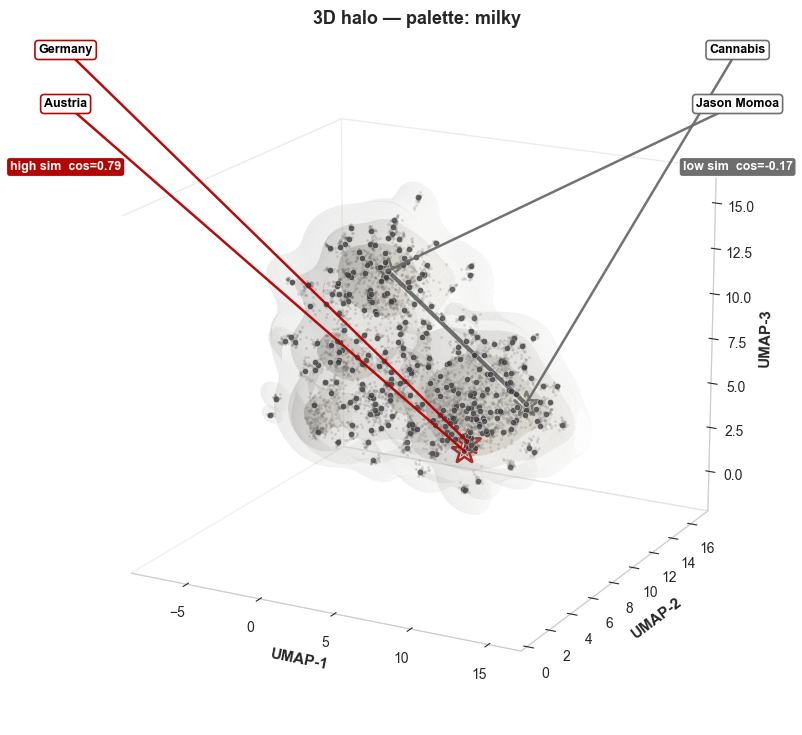

saved manifold_bars_halo_3d_milky.png


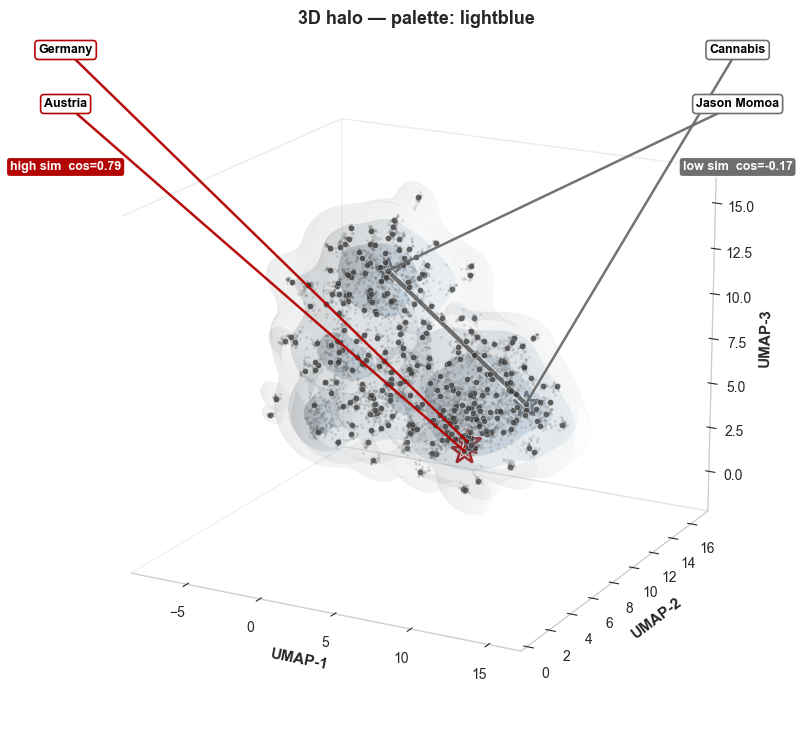

saved manifold_bars_halo_3d_lightblue.png


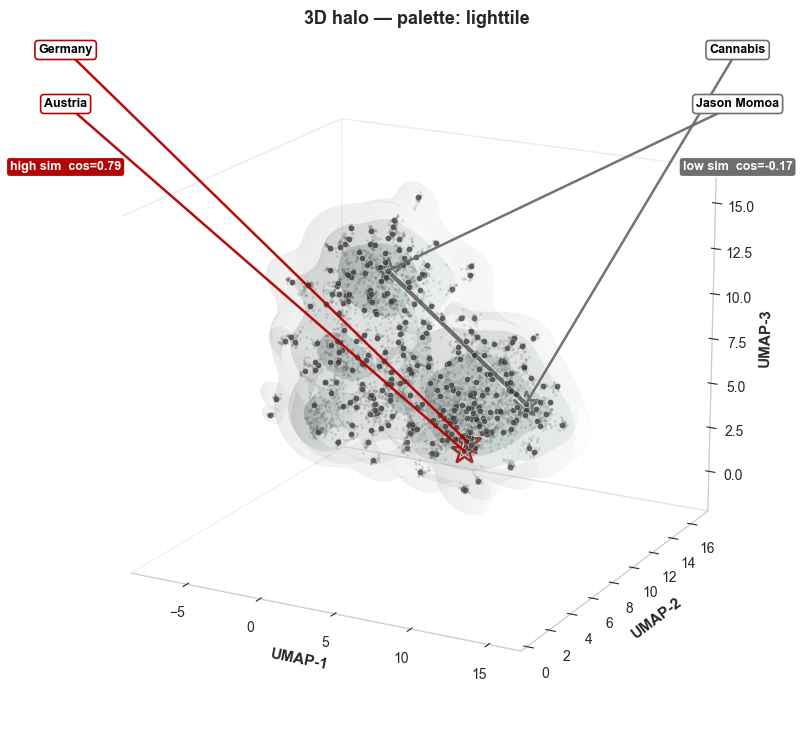

saved manifold_bars_halo_3d_lighttile.png


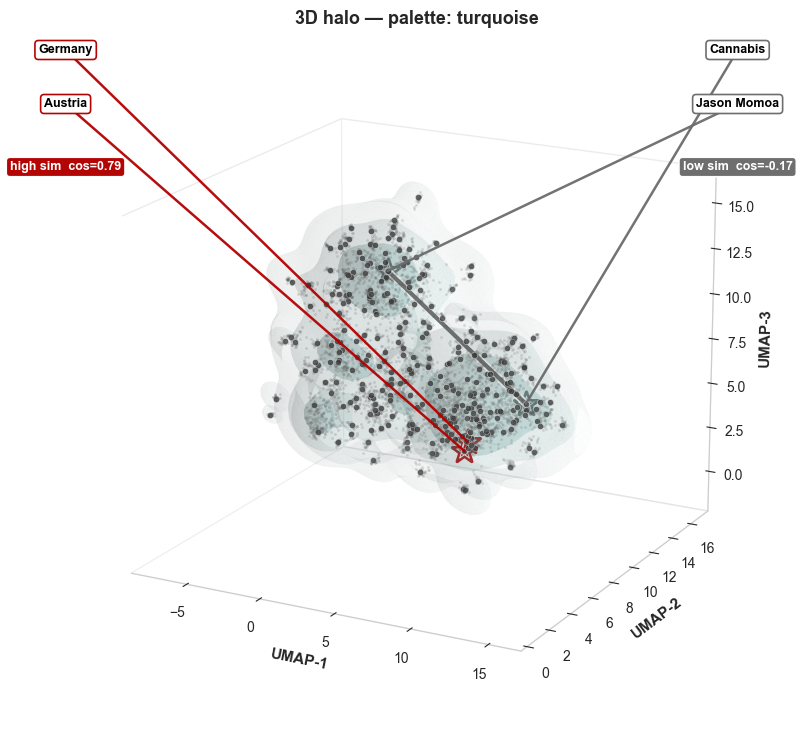

saved manifold_bars_halo_3d_turquoise.png


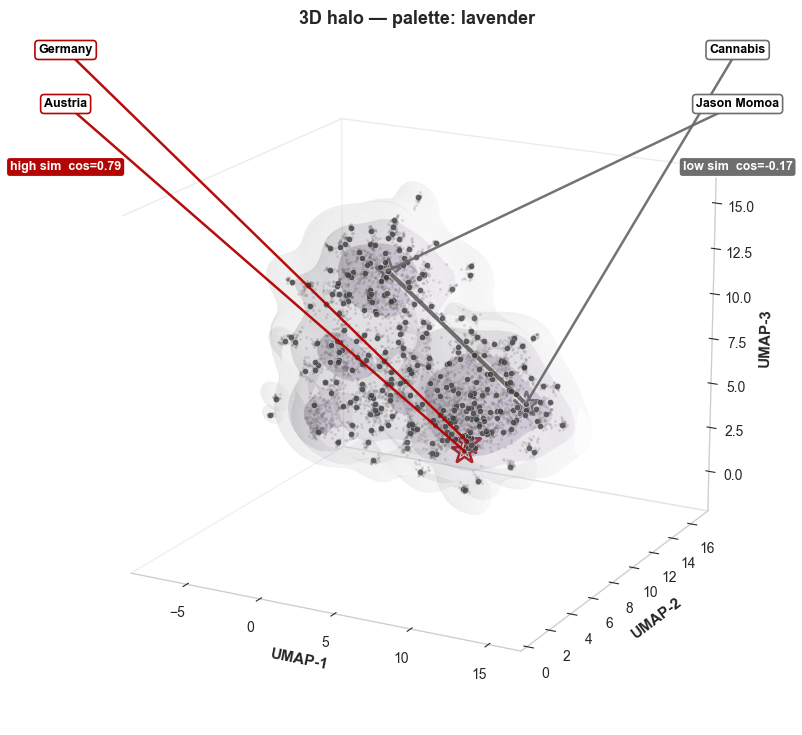

saved manifold_bars_halo_3d_lavender.png


In [9]:
# Halo color variants: render the 3D halo with several light palettes
PALETTES = {
    "milky":      ["#F2EDE4", "#E5DCC9", "#C9B89A"],
    "lightblue":  ["#DCEBF7", "#B7D4ED", "#7FB0DA"],
    "lighttile":  ["#DDEAE5", "#B6D2C8", "#7FB0A2"],
    "turquoise":  ["#D6F1F0", "#A8E0DD", "#5FBFB9"],
    "lavender":   ["#EFE6F4", "#D2BFE0", "#9B7FBF"],  # original-ish for reference
}

for name, shell_colors in PALETTES.items():
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    shell_levels = [0.06, 0.20, 0.45]
    shell_alphas = [0.05, 0.08, 0.13]
    spacing = (xs[1] - xs[0], ys[1] - ys[0], zs[1] - zs[0])
    origin = (xb[0], yb[0], zb[0])
    for level_frac, alpha, color in zip(shell_levels, shell_alphas, shell_colors):
        iso = level_frac * dmax
        if iso <= density.min() or iso >= density.max():
            continue
        verts, faces, _, _ = measure.marching_cubes(density, level=iso, spacing=spacing)
        verts = verts + np.array(origin)
        ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                        color=color, alpha=alpha, linewidth=0,
                        antialiased=True, shade=True, zorder=1)

    ax.scatter(q_3d[:, 0], q_3d[:, 1], q_3d[:, 2], s=4, alpha=0.18, color="#4A4A4A",
               linewidths=0, depthshade=False, zorder=3)
    ax.scatter(c_3d[:, 0], c_3d[:, 1], c_3d[:, 2], s=20, alpha=0.75, color="#2A2A2A",
               edgecolors="white", linewidths=0.4, depthshade=False, zorder=4)

    ax.set_xlabel("UMAP-1", fontsize=11, fontweight="bold")
    ax.set_ylabel("UMAP-2", fontsize=11, fontweight="bold")
    ax.set_zlabel("UMAP-3", fontsize=11, fontweight="bold")
    ax.set_title(f"3D halo — palette: {name}", fontsize=13, fontweight="bold")
    ax.grid(False)
    ax.view_init(elev=18, azim=-62)
    ax.set_box_aspect((1, 1, 0.85))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor((0.85, 0.85, 0.85, 0.6))

    for pair, color in [(hi_pair_3d, "#B30000"), (lo_pair_3d, "#6B6B6B")]:
        a, b = c_3d[pair[0]], c_3d[pair[1]]
        ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                color="white", linewidth=5.5, alpha=0.9, zorder=6)
        ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                color=color, linewidth=3.0, alpha=1.0, zorder=7)
        ax.scatter([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                   s=320, facecolors="white", edgecolors=color,
                   linewidths=2.4, marker="*", depthshade=False, zorder=8)
        ax.scatter([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                   s=140, facecolors=color, edgecolors="white",
                   linewidths=0.7, marker="*", depthshade=False, zorder=9)

    fig.canvas.draw()
    def _to_fig(pt3, ax=ax, fig=fig):
        x2, y2, _ = proj3d.proj_transform(pt3[0], pt3[1], pt3[2], ax.get_proj())
        return fig.transFigure.inverted().transform(ax.transData.transform((x2, y2)))
    def _trim(s, n=30):
        return s if len(s) <= n else s[: n - 1] + "…"
    def _label(pt3, anchor, text, color):
        p_ = _to_fig(pt3)
        fig.add_artist(plt.Line2D([p_[0], anchor[0]], [p_[1], anchor[1]],
                                  transform=fig.transFigure, color=color,
                                  linewidth=1.8, alpha=0.95, zorder=30))
        fig.text(anchor[0], anchor[1], text, ha="center", va="center",
                 fontsize=9, fontweight="bold", color="black",
                 bbox=dict(boxstyle="round,pad=0.28", facecolor="white",
                           edgecolor=color, linewidth=1.2, alpha=0.98),
                 zorder=31)
    def _tag(anchor, text, color):
        fig.text(anchor[0], anchor[1], text, ha="center", va="center",
                 fontsize=9, fontweight="bold", color="white",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor=color,
                           edgecolor="white", linewidth=1.2, alpha=0.98),
                 zorder=31)

    i, j = hi_pair_3d
    _label(c_3d[i], (0.22, 0.86), _trim(concept_keys.iloc[i]["concept"]), "#B30000")
    _label(c_3d[j], (0.22, 0.80), _trim(concept_keys.iloc[j]["concept"]), "#B30000")
    _tag((0.22, 0.73), f"high sim  cos={hi_sim_3d:.2f}", "#B30000")
    i, j = lo_pair_3d
    _label(c_3d[i], (0.78, 0.86), _trim(concept_keys.iloc[i]["concept"]), "#6B6B6B")
    _label(c_3d[j], (0.78, 0.80), _trim(concept_keys.iloc[j]["concept"]), "#6B6B6B")
    _tag((0.78, 0.73), f"low sim  cos={lo_sim_3d:.2f}", "#6B6B6B")

    out_png = RESULTS_DIR / f"manifold_bars_halo_3d_{name}.png"
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(RESULTS_DIR / f"manifold_bars_halo_3d_{name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print("saved", out_png.name)
